Table 1- Summary Statistics

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/clean/merged_final.csv', parse_dates=['month'])
df = df[df['month'] <= '2025-12-01']

# Create total patronage from individual modes if missing
patronage_cols = [
    'Metropolitan train', 'Metropolitan tram', 'Metropolitan bus',
    'Regional train', 'Regional coach', 'Regional bus'
]
if 'total_patronage' not in df.columns:
    df['total_patronage'] = df[patronage_cols].sum(axis=1)

# Select key variables
vars_of_interest = ['PetrolPrice', 'total_patronage', 'rainfall_mm', 'population', 'public_holiday_count']

# Create summary stats table
summary = df[vars_of_interest].describe().T[['count', 'mean', 'std', 'min', 'max']]
summary.columns = ['N', 'Mean', 'Std Dev', 'Min', 'Max']

# Rename rows for clean labels
summary.index = ['Petrol Price ($/L)', 'Total Patronage (persons)', 
                 'Rainfall (mm)', 'Population', 'Public Holiday Count']

print(summary.round(2).to_string())

                              N         Mean     Std Dev          Min          Max
Petrol Price ($/L)         48.0         1.88        0.10         1.59         2.12
Total Patronage (persons)  48.0  38286542.42  5665613.86  16553521.00  47552413.00
Rainfall (mm)              48.0        50.80       33.04         2.80       149.00
Population                 48.0   6921754.25   130348.70   6714248.00   7104348.00
Public Holiday Count       48.0         1.17        1.42         0.00         5.00


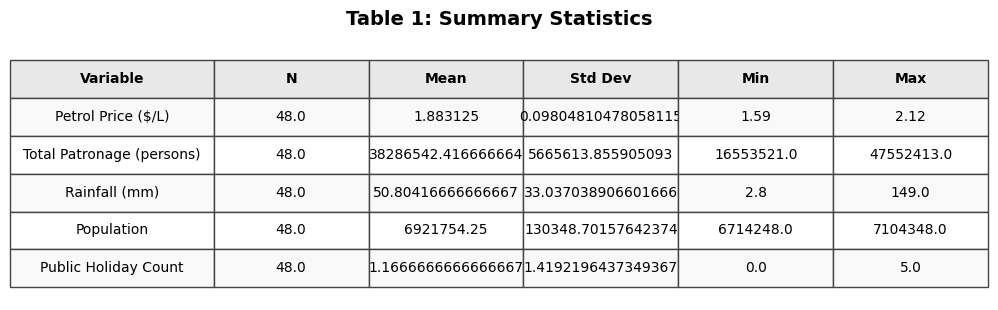

In [11]:
import os
import matplotlib.pyplot as plt

# Build a cleaner screenshot-friendly table image
styled = summary.copy().reset_index()
styled.rename(columns={'index': 'Variable'}, inplace=True)

num_cols = len(styled.columns)
col_widths = [0.25] + [0.19] * (num_cols - 1)
fig_width = max(10, num_cols * 1.1)
fig, ax = plt.subplots(figsize=(fig_width, 3.2))
ax.axis('off')
ax.set_title('Table 1: Summary Statistics', fontsize=14, fontweight='bold', pad=16)

header_color = ['#e8e8e8'] * num_cols

table = ax.table(
    cellText=styled.values,
    colLabels=styled.columns,
    cellLoc='center',
    loc='center',
    colColours=header_color,
    colWidths=col_widths
)

table.auto_set_font_size(False)
table.set_fontsize(10)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#444444')
    cell.set_height(0.15)
    if row == 0:
        cell.set_facecolor('#e8e8e8')
        cell.get_text().set_weight('bold')
    elif row % 2 == 1:
        cell.set_facecolor('#f9f9f9')
    else:
        cell.set_facecolor('#ffffff')

plt.tight_layout()
os.makedirs('../output', exist_ok=True)
fig.savefig('../output/table1_summary.png', dpi=220, bbox_inches='tight')
plt.show()